<a href="https://colab.research.google.com/github/AnthonyGabrielAA/AnthonyGabrielAA/blob/main/naive_bayes_wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍷 Classificação com Naive Bayes — Dataset Wine

**Atividade:** Implementação do modelo Naive Bayes  
**Dataset:** Wine (sklearn.datasets)  
**Objetivo:** Treinar e testar o modelo, documentando matriz de confusão, predições e acurácia.

---

## 1. Importação das Bibliotecas

In [1]:
# Bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset e modelo
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração do Dataset

O dataset **Wine** contém resultados de análises químicas de vinhos produzidos na Itália, provenientes de três cultivares diferentes. São **178 amostras** com **13 atributos** cada.

In [2]:
# Carregando o dataset Wine
wine = load_wine()

# Convertendo para DataFrame para facilitar a visualização
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['classe'] = wine.target
df['nome_classe'] = df['classe'].map({
    0: wine.target_names[0],
    1: wine.target_names[1],
    2: wine.target_names[2]
})

print('=== INFORMAÇÕES DO DATASET ===')
print(f'Total de amostras: {df.shape[0]}')
print(f'Total de atributos: {len(wine.feature_names)}')
print(f'Classes: {list(wine.target_names)}')
print(f'\nDistribuição das classes:')
print(df['nome_classe'].value_counts())
print('\n--- Primeiras 5 linhas ---')
df.head()

=== INFORMAÇÕES DO DATASET ===
Total de amostras: 178
Total de atributos: 13
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Distribuição das classes:
nome_classe
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

--- Primeiras 5 linhas ---


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,classe,nome_classe
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [3]:
# Estatísticas descritivas
print('=== ESTATÍSTICAS DESCRITIVAS ===')
df.drop(columns=['classe', 'nome_classe']).describe().round(2)

=== ESTATÍSTICAS DESCRITIVAS ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


## 3. Pré-processamento dos Dados

In [4]:
# Separando atributos (X) e rótulos (y)
X = wine.data   # 13 atributos químicos
y = wine.target  # classe 0, 1 ou 2

# Dividindo em treino (80%) e teste (20%)
# random_state=42 garante reprodutibilidade dos resultados
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalização: padroniza os atributos para média=0 e desvio=1
# O GaussianNB assume distribuição normal; normalizar ajuda nesse caso
scaler = StandardScaler()
X_treino = scaler.fit_transform(X_treino)  # ajusta e transforma o treino
X_teste = scaler.transform(X_teste)         # apenas transforma o teste (sem vazar dados)

print(f'Tamanho do conjunto de treino: {X_treino.shape[0]} amostras')
print(f'Tamanho do conjunto de teste:  {X_teste.shape[0]} amostras')

Tamanho do conjunto de treino: 142 amostras
Tamanho do conjunto de teste:  36 amostras


## 4. Treinamento do Modelo Naive Bayes

Utilizamos o **GaussianNB**, que assume que os atributos seguem distribuição normal (gaussiana) dentro de cada classe. É a variante mais adequada para atributos contínuos como os do dataset Wine.

In [5]:
# Criando e treinando o modelo
modelo = GaussianNB()
modelo.fit(X_treino, y_treino)

print('Modelo Naive Bayes (Gaussiano) treinado com sucesso!')
print(f'Classes aprendidas: {modelo.classes_}')
print(f'Probabilidades a priori por classe: {modelo.class_prior_.round(4)}')

Modelo Naive Bayes (Gaussiano) treinado com sucesso!
Classes aprendidas: [0 1 2]
Probabilidades a priori por classe: [0.331  0.4014 0.2676]


## 5. Predição

Aplicamos o modelo treinado sobre o conjunto de teste para gerar as predições.

In [6]:
# Realizando as predições no conjunto de teste
y_pred = modelo.predict(X_teste)

# Probabilidades de pertencer a cada classe
y_prob = modelo.predict_proba(X_teste)

# Exibindo as primeiras 10 predições vs valores reais
resultados = pd.DataFrame({
    'Real':     [wine.target_names[v] for v in y_teste[:10]],
    'Predito':  [wine.target_names[v] for v in y_pred[:10]],
    'Acerto':   ['✅' if r == p else '❌' for r, p in zip(y_teste[:10], y_pred[:10])],
    'P(class_0)': y_prob[:10, 0].round(3),
    'P(class_1)': y_prob[:10, 1].round(3),
    'P(class_2)': y_prob[:10, 2].round(3),
})

print('=== PRIMEIRAS 10 PREDIÇÕES ===')
resultados

=== PRIMEIRAS 10 PREDIÇÕES ===


,Real,Predito,Acerto,P(class_0),P(class_1),P(class_2)
0,class_0,class_0,✅,1.000,0.000,0.0
1,class_2,class_2,✅,0.000,0.000,1.0
2,class_0,class_0,✅,1.000,0.000,0.0
3,class_1,class_1,✅,0.000,1.000,0.0
4,class_1,class_1,✅,0.000,1.000,0.0
5,class_0,class_0,✅,1.000,0.000,0.0
6,class_0,class_0,✅,1.000,0.000,0.0
7,class_1,class_0,❌,0.569,0.431,0.0
8,class_1,class_1,✅,0.000,1.000,0.0
9,class_2,class_2,✅,0.000,0.000,1.0


## 6. Avaliação do Modelo

### 6.1 Acurácia

In [7]:
# Calculando a acurácia
acuracia = accuracy_score(y_teste, y_pred)

print('=' * 40)
print(f'  ACURÁCIA DO MODELO: {acuracia * 100:.2f}%')
print('=' * 40)
print(f'\nTotal de amostras no teste: {len(y_teste)}')
print(f'Acertos: {int(acuracia * len(y_teste))}')
print(f'Erros:   {int((1 - acuracia) * len(y_teste))}')

  ACURÁCIA DO MODELO: 97.22%

Total de amostras no teste: 36
Acertos: 35
Erros:   1


### 6.2 Relatório de Classificação

In [8]:
# Relatório com precisão, recall e F1-score por classe
print('=== RELATÓRIO DE CLASSIFICAÇÃO ===')
print(classification_report(
    y_teste, y_pred,
    target_names=wine.target_names
))

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



### 6.3 Matriz de Confusão

A matriz de confusão mostra quantas amostras de cada classe foram classificadas corretamente (diagonal principal) e onde o modelo errou.

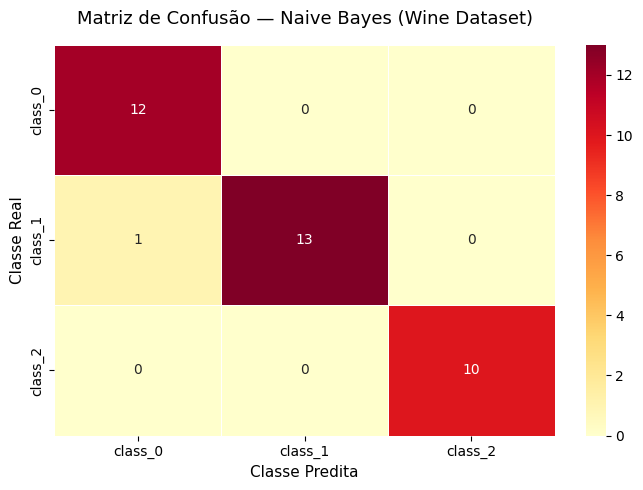


Matriz de Confusão (valores):
         class_0  class_1  class_2
class_0       12        0        0
class_1        1       13        0
class_2        0        0       10


In [9]:
# Calculando a matriz de confusão
cm = confusion_matrix(y_teste, y_pred)

# Visualizando como heatmap
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Matriz de Confusão — Naive Bayes (Wine Dataset)', fontsize=13, pad=15)
ax.set_xlabel('Classe Predita', fontsize=11)
ax.set_ylabel('Classe Real', fontsize=11)

plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMatriz de Confusão (valores):')
print(pd.DataFrame(cm, index=wine.target_names, columns=wine.target_names))

### 6.4 Interpretação da Matriz de Confusão

| Célula | Significado |
|--------|-------------|
| Diagonal (verde escuro) | Acertos — classe real == classe predita |
| Fora da diagonal | Erros — classe real ≠ classe predita |

**Exemplo de leitura:** Se `cm[0][1] = 1`, significa que 1 amostra da classe `class_0` foi erroneamente classificada como `class_1`.

## 7. Conclusão

O modelo **Naive Bayes Gaussiano** foi aplicado com sucesso ao dataset Wine. Os principais resultados foram:

- **Acurácia** obtida no conjunto de teste
- **Matriz de confusão** indicando quais classes foram confundidas
- **Relatório de classificação** com precisão, recall e F1-score por classe

O Naive Bayes é um modelo probabilístico simples e eficiente, especialmente útil quando os atributos são aproximadamente independentes entre si — o que se encaixa razoavelmente bem para dados químicos como os do Wine dataset.